<a href="https://colab.research.google.com/github/DreanoLucas/ML_AIR_Attack/blob/main/KDD_Kamarul_exploration_and_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploration — Project KDD (NSL-KDD)

Network **attack detection**. We explore the `KDDTrain+_20Percent` subset of NSL-KDD before any
learning. This notebook follows the **same structure and methods** as the course exploration
notebook (`01.introduction/b.exploration`), applied to our dataset:

`describe` → 1st/2nd-order statistics → boxplots & percentiles → histograms → correlations
(`scatter_matrix`, Pearson) → feature importance → **log transformation** → train/test prep.

The custom course helpers (`visualization`, `feature_engineering`) are **reproduced inline** below,
so this notebook is self-contained (no need to clone the course library).

## Load libraries

In [ ]:
import pandas as pd          # dataframes (tables)
import numpy as np             # numerical operations
import math
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

pd.set_option('display.max_columns', 60)
plt.rcParams['figure.figsize'] = (8,4)

### Course helpers, reproduced inline
These mirror `visualization.rotate_labels`, `visualization.plot_corr` and
`feature_engineering.get_features_correlated_to_target` from the course library.

In [ ]:
def rotate_labels(sm, x_rot=90, y_rot=0):
    # Rotate the axis labels of a scatter_matrix so they are readable.
    for ax in sm.ravel():
        ax.set_xlabel(ax.get_xlabel(), rotation=x_rot)
        ax.set_ylabel(ax.get_ylabel(), rotation=y_rot, ha='right', va='center')

def plot_corr(df, width=10, height=10, print_value=False):
    # Heatmap of the Pearson correlation matrix of the numeric columns of df.
    corr = df.corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(width, height))
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
    ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns, fontsize=7)
    fig.colorbar(im, shrink=0.7)
    if print_value:
        for i in range(len(corr)):
            for j in range(len(corr)):
                ax.text(j, i, f'{corr.iloc[i,j]:.1f}', ha='center', va='center', fontsize=6)
    plt.tight_layout(); plt.show()

def get_features_correlated_to_target(df, target_feature):
    # Return features sorted by |Pearson correlation| with the target.
    corr = df.corr(numeric_only=True)[target_feature].drop(target_feature)
    return corr.abs().sort_values(ascending=False)

## Load the dataset

On **Colab**: upload `KDDTrain__20Percent.txt` (drag it into the file panel on the left, or run the
cell — an upload widget appears if the file is missing). Our file already has a header row with the
41 feature names + `attack` + `level`. If yours has no header, set `HAS_HEADER=False`.

In [ ]:
FILENAME = 'KDDTrain__20Percent.txt'
HAS_HEADER = True

COL_NAMES = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells','num_access_files',
    'num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
    'dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','attack','level']

import os
if not os.path.exists(FILENAME):
    try:
        from google.colab import files
        up = files.upload(); FILENAME = list(up.keys())[0]
    except Exception:
        raise FileNotFoundError(f'{FILENAME} not found and not on Colab.')

df = pd.read_csv(FILENAME) if HAS_HEADER else pd.read_csv(FILENAME, header=None, names=COL_NAMES)
df.columns = COL_NAMES
print('shape:', df.shape)

Saving KDDTrain+_20Percent.txt to KDDTrain+_20Percent.txt
shape: (25192, 43)


In [ ]:
df.head(n=11)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
5,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,121,19,0.0,0.0,1.0,1.0,0.16,0.06,0.00,255,19,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21
6,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,166,9,1.0,1.0,0.0,0.0,0.05,0.06,0.00,255,9,0.04,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
7,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,117,16,1.0,1.0,0.0,0.0,0.14,0.06,0.00,255,15,0.06,0.07,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
8,0,tcp,remote_job,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,270,23,1.0,1.0,0.0,0.0,0.09,0.05,0.00,255,23,0.09,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
9,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,133,8,1.0,1.0,0.0,0.0,0.06,0.06,0.00,255,13,0.05,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21


In [ ]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     25192 non-null  int64  
 1   protocol_type                25192 non-null  object 
 2   service                      25192 non-null  object 
 3   flag                         25192 non-null  object 
 4   src_bytes                    25192 non-null  int64  
 5   dst_bytes                    25192 non-null  int64  
 6   land                         25192 non-null  int64  
 7   wrong_fragment               25192 non-null  int64  
 8   urgent                       25192 non-null  int64  
 9   hot                          25192 non-null  int64  
 10  num_failed_logins            25192 non-null  int64  
 11  logged_in                    25192 non-null  int64  
 12  num_compromised              25192 non-null  int64  
 13  root_shell      

### Meaning of the columns
The 41 features describe a network connection: basic TCP info (`duration`, `protocol_type`,
`service`, `flag`, `src_bytes`, `dst_bytes`), content features (`hot`, `num_failed_logins`,
`logged_in`, ...), and traffic statistics over a time window (`count`, `serror_rate`,
`same_srv_rate`, `dst_host_*`...). `attack` is the label, `level` is a difficulty score (0–21).

**Check the values a categorical feature can take:**

In [ ]:
print('Values of attack:', df['attack'].unique())
print('\nValues of protocol_type:', df['protocol_type'].unique())
print('Values of flag:', df['flag'].unique())

Values of attack: ['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop'
 'rootkit' 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land'
 'loadmodule' 'spy']

Values of protocol_type: ['tcp' 'udp' 'icmp']
Values of flag: ['SF' 'S0' 'REJ' 'RSTR' 'SH' 'RSTO' 'S1' 'RSTOS0' 'S3' 'S2' 'OTH']


### Build the labels
We add a **binary** target `is_attack` (1=attack, 0=normal) — the numeric target we will correlate
features against — and a **category** label grouping the 22 attack types into the 4 standard NSL-KDD
classes (DoS, Probe, R2L, U2R).

In [ ]:
attack_category = {
    'neptune':'DoS','smurf':'DoS','back':'DoS','teardrop':'DoS','pod':'DoS','land':'DoS',
    'apache2':'DoS','processtable':'DoS','mailbomb':'DoS','udpstorm':'DoS','worm':'DoS',
    'satan':'Probe','ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','mscan':'Probe','saint':'Probe',
    'guess_passwd':'R2L','ftp_write':'R2L','imap':'R2L','phf':'R2L','multihop':'R2L','warezmaster':'R2L',
    'warezclient':'R2L','spy':'R2L','xlock':'R2L','xsnoop':'R2L','snmpguess':'R2L','snmpgetattack':'R2L',
    'httptunnel':'R2L','sendmail':'R2L','named':'R2L',
    'buffer_overflow':'U2R','loadmodule':'U2R','rootkit':'U2R','perl':'U2R','sqlattack':'U2R',
    'xterm':'U2R','ps':'U2R'}
df['category'] = df['attack'].apply(lambda a: 'normal' if a=='normal' else attack_category.get(a,'unknown'))
df['is_attack'] = (df['attack']!='normal').astype(int)
print('unmapped (should be empty):', df.loc[df.category=='unknown','attack'].unique())
print('\nBinary balance (%):'); print((df['is_attack'].value_counts(normalize=True)*100).round(1))
print('\nBy category:'); print(df['category'].value_counts())

unmapped (should be empty): []

Binary balance (%):
is_attack
0    53.4
1    46.6
Name: proportion, dtype: float64

By category:
category
normal    13449
DoS        9234
Probe      2289
R2L         209
U2R          11
Name: count, dtype: int64


**Discuss:** the **binary** task is almost balanced (~53% normal / 47% attack), but the
**multi-class** task is extremely imbalanced: DoS is huge while U2R has only ~11 samples and R2L ~200.
This is the central difficulty of NSL-KDD and motivates grouping rare attacks or a cascade
(attack/normal first, then attack-type).

# Basic statistics

In [ ]:
df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,level,is_attack
count,25192.000000,2.519200e+04,2.519200e+04,25192.000000,25192.000000,25192.00000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.0,25192.0,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000
mean,305.054104,2.433063e+04,3.491847e+03,0.000079,0.023738,0.00004,0.198039,0.001191,0.394768,0.227850,0.001548,0.001350,0.249841,0.014727,0.000357,0.004327,0.0,0.0,0.009130,84.591180,27.698754,0.286338,0.283762,0.118630,0.120260,0.660559,0.062363,0.095931,182.532074,115.063036,0.519791,0.082539,0.147453,0.031844,0.285800,0.279846,0.117800,0.118769,19.487695,0.466140
std,2686.555640,2.410805e+06,8.883072e+04,0.008910,0.260221,0.00630,2.154202,0.045418,0.488811,10.417352,0.039316,0.048785,11.500842,0.529602,0.018898,0.098524,0.0,0.0,0.095115,114.673451,72.468242,0.447312,0.447599,0.318745,0.322335,0.439637,0.178550,0.256583,98.993895,110.646850,0.448944,0.187191,0.308367,0.110575,0.445316,0.446075,0.305869,0.317333,2.328541,0.498862
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.090000,0.000000,0.000000,84.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,14.000000,8.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,61.000000,0.510000,0.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000
75%,0.000000,2.790000e+02,5.302500e+02,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,144.000000,18.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.060000,0.000000,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000,1.000000
max,42862.000000,3.817091e+08,5.151385e+06,1.000000,3.000000,1.00000,77.000000,4.000000,1.000000,884.000000,1.000000,2.000000,975.000000,40.000000,1.000000,8.000000,0.0,0.0,1.000000,511.000000,511.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000,1.000000


See **all** columns at once (including categoricals):

In [ ]:
with pd.option_context('display.max_columns', df.shape[1]):
    print(df.describe(include='all'))

            duration protocol_type service   flag     src_bytes     dst_bytes  \
count   25192.000000         25192   25192  25192  2.519200e+04  2.519200e+04   
unique           NaN             3      66     11           NaN           NaN   
top              NaN           tcp    http     SF           NaN           NaN   
freq             NaN         20526    8003  14973           NaN           NaN   
mean      305.054104           NaN     NaN    NaN  2.433063e+04  3.491847e+03   
std      2686.555640           NaN     NaN    NaN  2.410805e+06  8.883072e+04   
min         0.000000           NaN     NaN    NaN  0.000000e+00  0.000000e+00   
25%         0.000000           NaN     NaN    NaN  0.000000e+00  0.000000e+00   
50%         0.000000           NaN     NaN    NaN  4.400000e+01  0.000000e+00   
75%         0.000000           NaN     NaN    NaN  2.790000e+02  5.302500e+02   
max     42862.000000           NaN     NaN    NaN  3.817091e+08  5.151385e+06   

                land  wrong

## 1st and 2nd order statistics

If we have $m$ samples, statistics of the $j$-th feature:

| | | |
|---|---|:--|
| Mean | $\mu_j \triangleq$ | $\frac{1}{m}\sum_{i=1}^m x_j^{(i)}$ |
| Variance | $\text{Var}(x_j) \triangleq$ | $\frac{1}{m-1}\sum_{i=1}^m \left(x_j^{(i)} - \bar{x}_j\right)^2$ |
| Standard deviation | $\sigma_j \triangleq$ | $\sqrt{\text{Var}(x_j)}$ |

Note: the $m-1$ (instead of $m$) is the *sample* variance correction — see Wikipedia
(not important to retain).

In [ ]:
x = df['src_bytes']
print('src_bytes:  mean =', round(x.mean(),2),
      '| var =', round(x.var(),2), '| std =', round(x.std(),2))
# pandas uses m-1 (ddof=1) by default, matching the formula above
print('manual var (m-1):', round(((x - x.mean())**2).sum()/(len(x)-1), 2))

src_bytes:  mean = 24330.63 | var = 5811982686441.94 | std = 2410805.4
manual var (m-1): 5811982686446.22


## Boxplot

A boxplot shows minimum, percentiles (25%, 50%, 75%) and maximum.

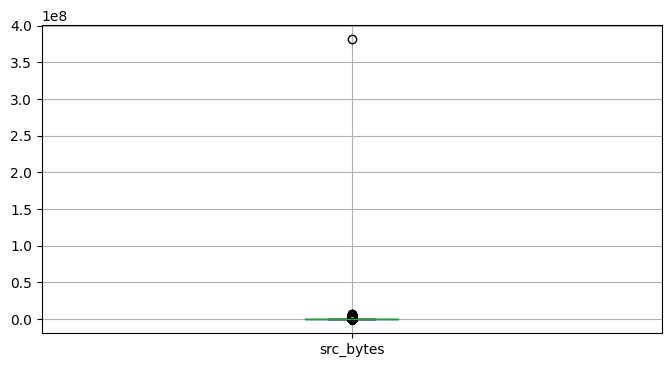

In [ ]:
df.boxplot(column=['src_bytes']); plt.show()

`src_bytes` is so skewed the box is invisible — everything is squashed by the huge outliers.
This already tells us we will need a transformation later.

#### Percentiles — how are 25% / 50% (median) / 75% computed?

In [ ]:
X = df['count'].values   # use 'count' (connection count) as a clean integer example
X_sorted = np.sort(X)
K = X_sorted.size
stop = math.ceil(K/100 * 25)
print('The 25% percentile is', X_sorted[stop])
print('--> 25% of the connections have count <=', X_sorted[stop])
print('pandas check:', df['count'].quantile(0.25))

The 25% percentile is 2
--> 25% of the connections have count <= 2
pandas check: 2.0


#### Outliers
Inter-Quartile Range (the box): $\text{IQR} \triangleq 75p - 25p$

Upper **whisker**: $\min(75p + 1.5\cdot\text{IQR},\ \max)$ &nbsp;&nbsp;
Lower **whisker**: $\max(25p - 1.5\cdot\text{IQR},\ \min)$

All points outside the whiskers are **outliers**.

Boxplot of several columns, and **grouped by class** (`by=`):

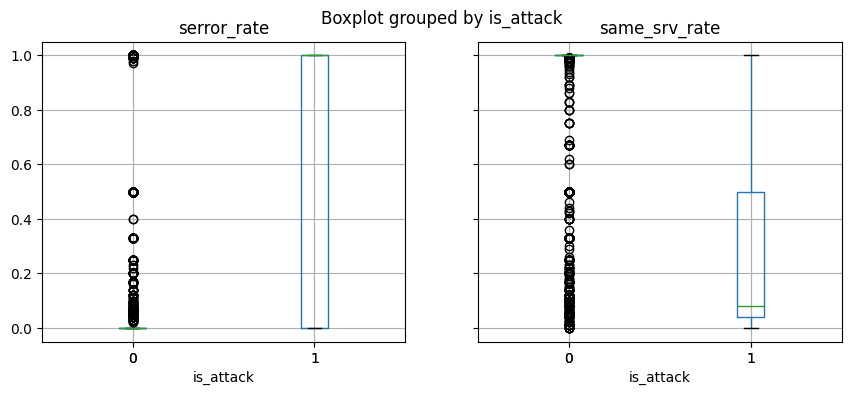

In [ ]:
df.boxplot(column=['serror_rate','same_srv_rate'], by='is_attack', figsize=(10,4)); plt.show()

**Discuss:** `serror_rate` and `same_srv_rate` clearly separate attack (1) from normal (0) —
their boxes barely overlap. These are promising predictors.

## Histogram

All features at once (quick overview):

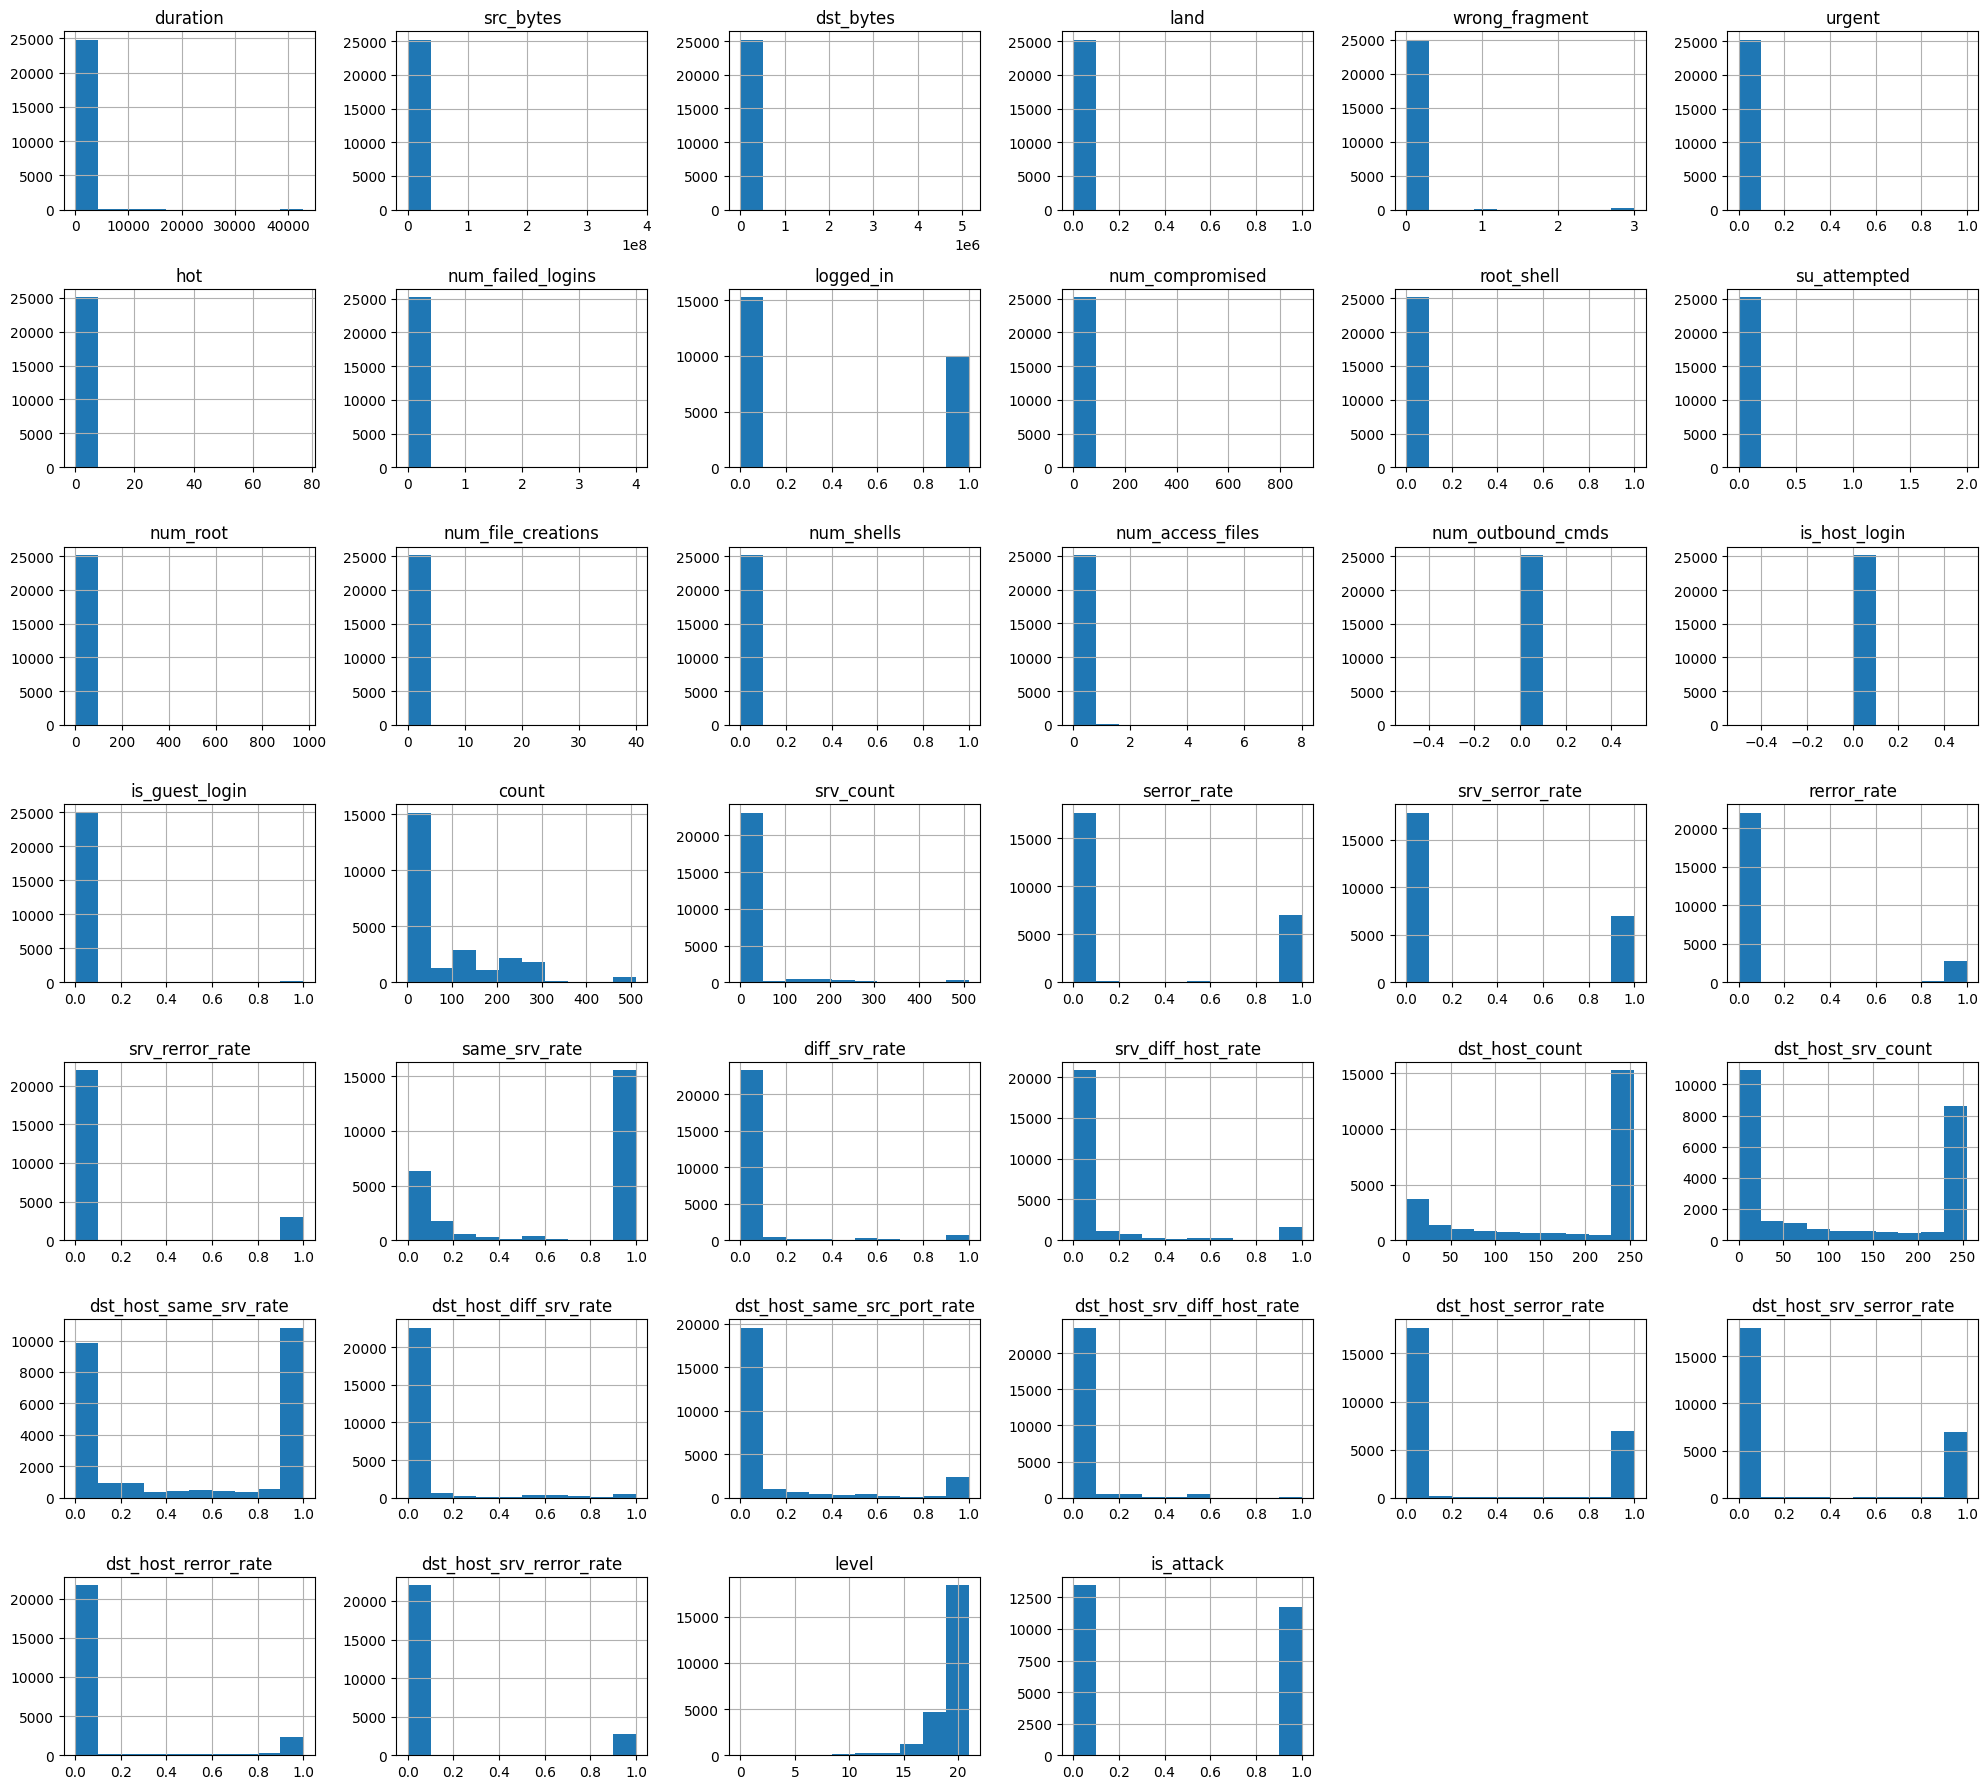

In [ ]:
df.hist(figsize=(20,18)); plt.tight_layout(); plt.show()

Too many to read — select a few informative ones:

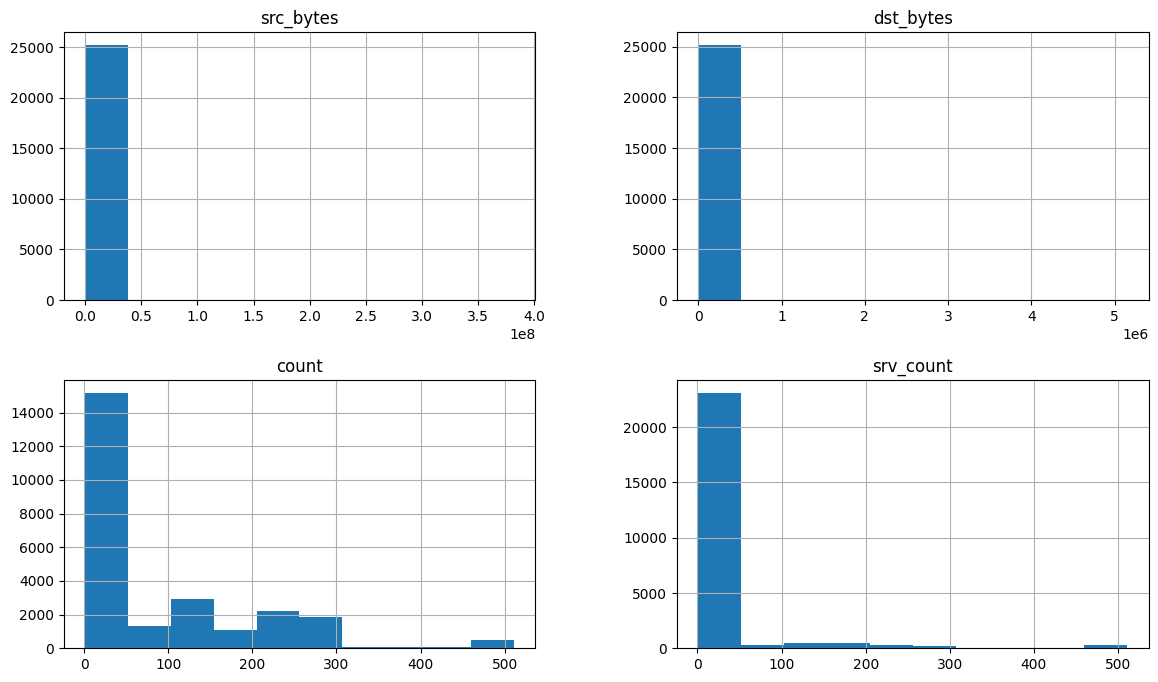

In [ ]:
df[['src_bytes','dst_bytes','count','srv_count']].hist(figsize=(14,8)); plt.show()

#### Binning
A histogram is a discretized probability density. The number of bins matters:

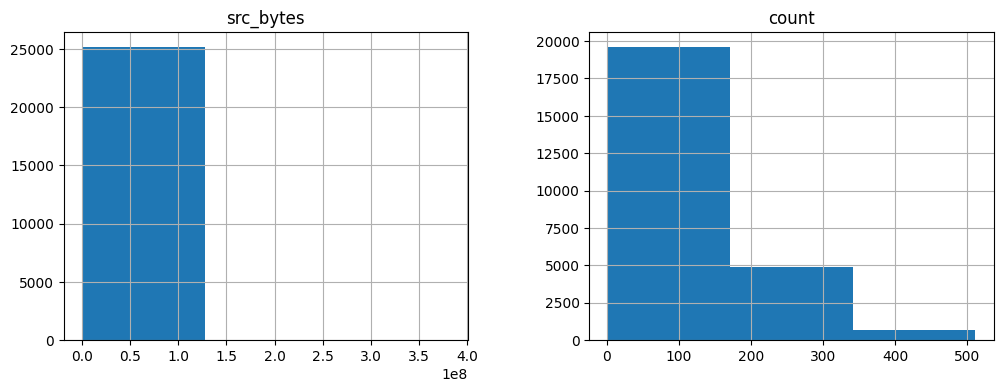

In [ ]:
df[['src_bytes','count']].hist(bins=3, figsize=(12,4)); plt.show()

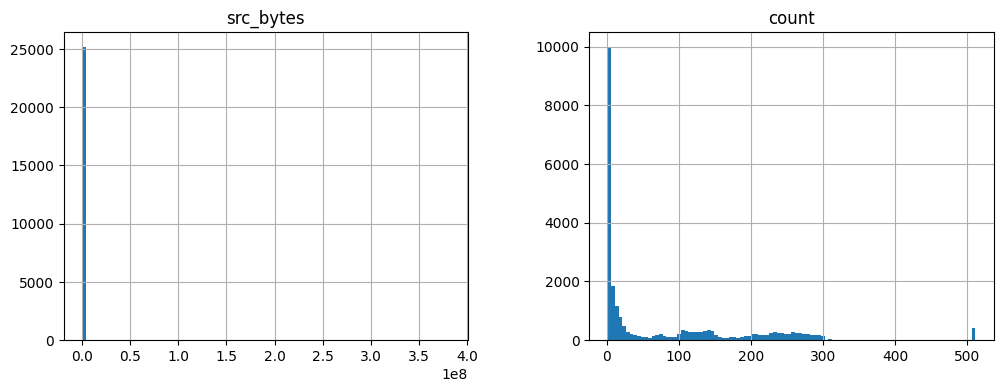

In [ ]:
df[['src_bytes','count']].hist(bins=100, figsize=(12,4)); plt.show()

Too few bins → the shape is lost; too many → each bin has too few samples.
**Rule of thumb:** more samples ⇒ more bins. Trial and error.

#### Group by
How does a feature's distribution change with the class? (`sharex=True` keeps a common x-axis.)

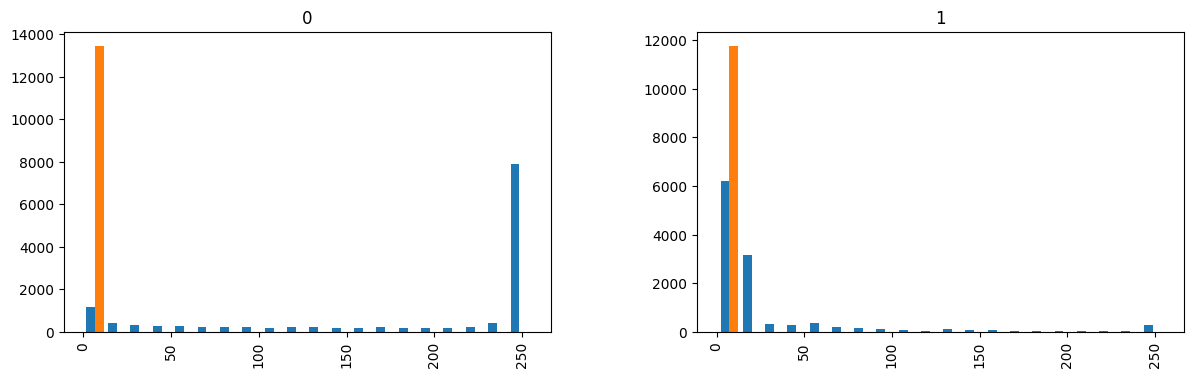

In [ ]:
df[['dst_host_srv_count','is_attack']].hist(figsize=(14,4), by='is_attack',
                                            sharex=True, bins=20, layout=(1,2)); plt.show()

**Discuss:** for `normal` (0), `dst_host_srv_count` concentrates at high values; for attacks (1)
it spreads toward low values. This suggests a simple rule-of-thumb classifier and confirms the
feature is informative — useful for **classification**.

# Correlations

How do features relate to each other? `scatter_matrix` plots every pair. With many columns it is
slow, so we select a few. (`label`-style target here is `is_attack`.)

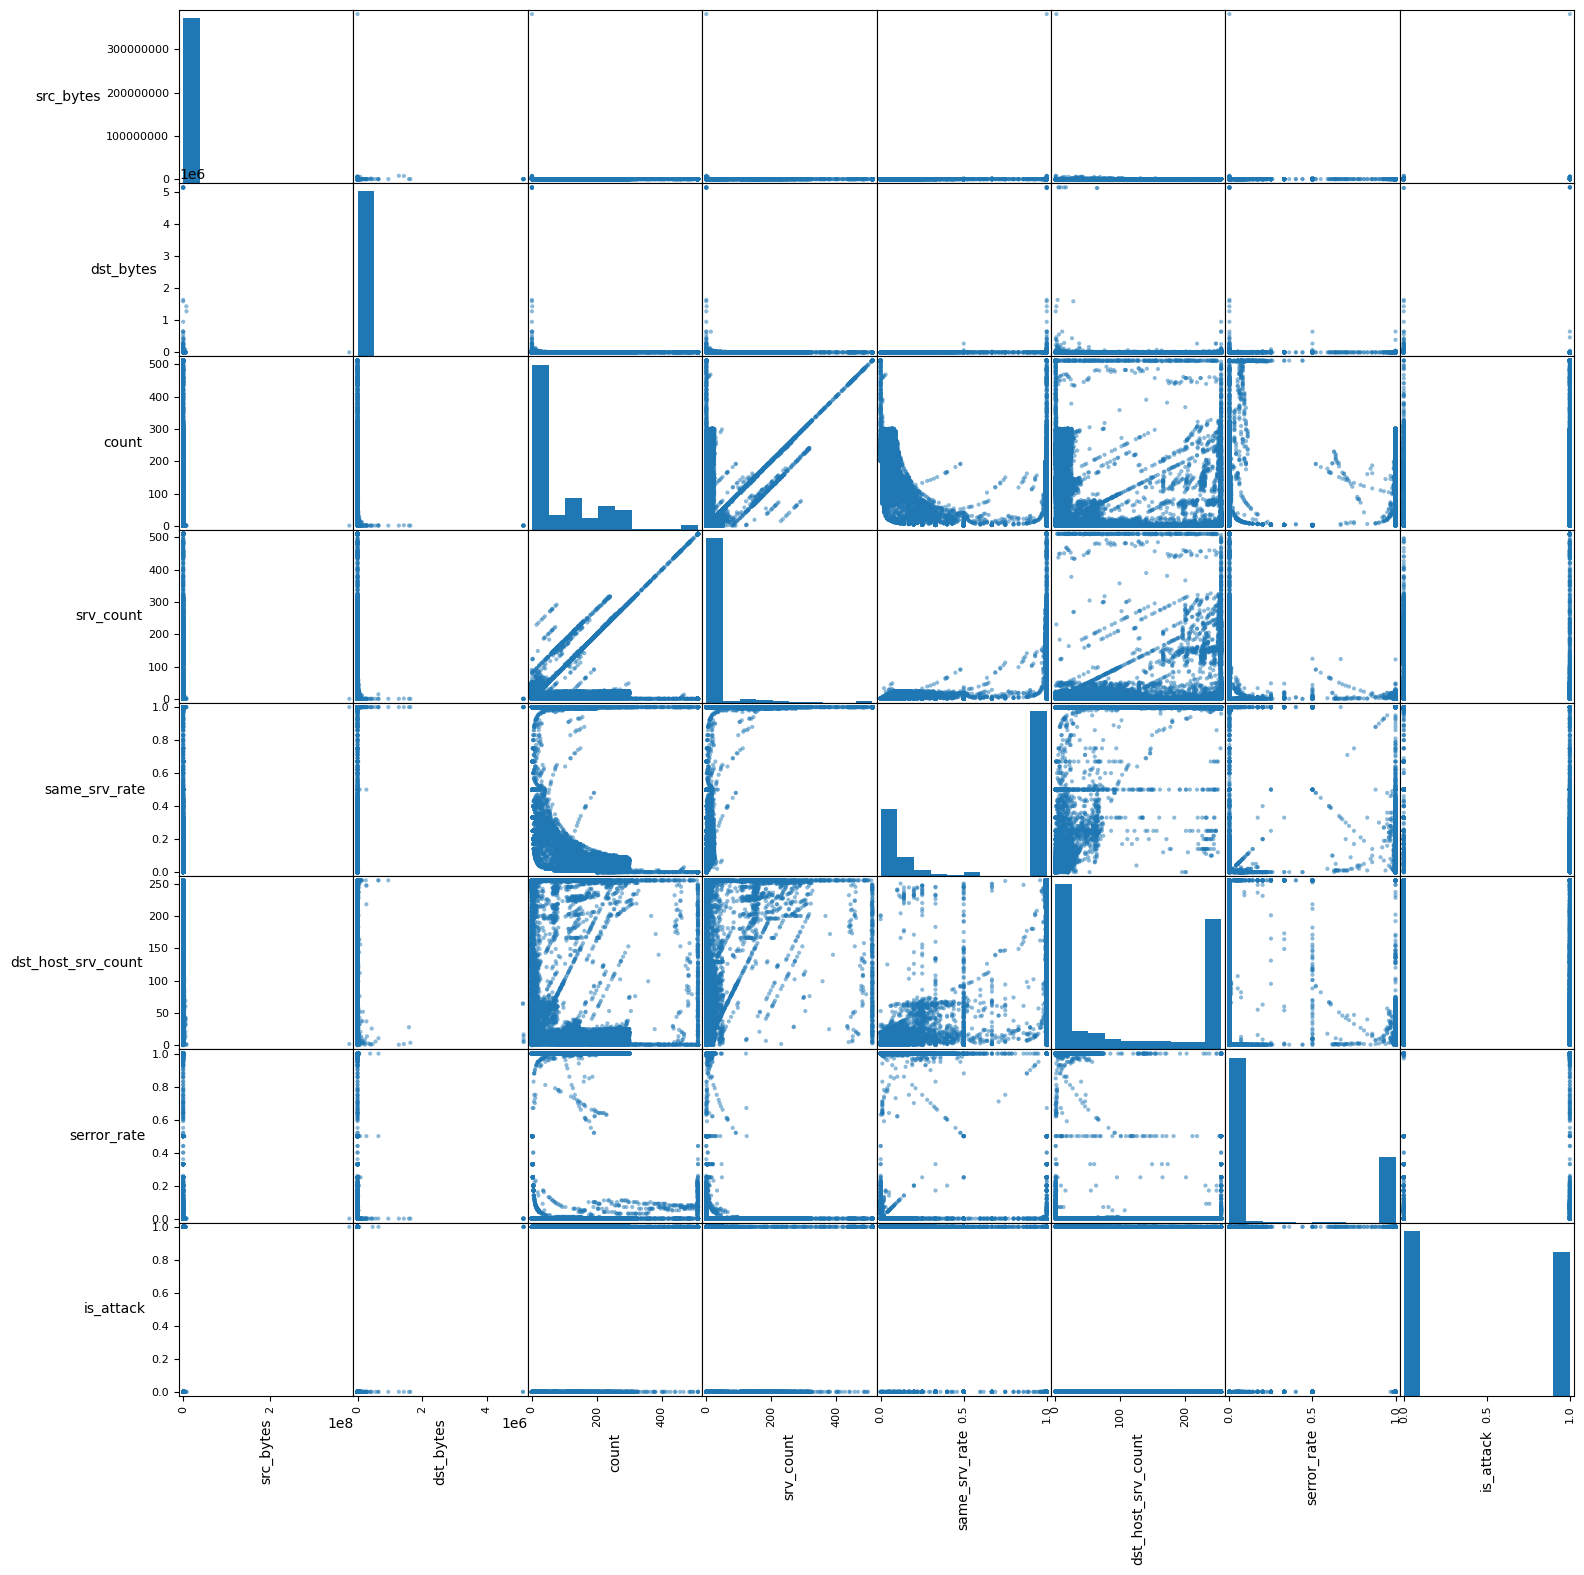

In [ ]:
columns_to_plot = ['src_bytes','dst_bytes','count','srv_count',
                   'same_srv_rate','dst_host_srv_count','serror_rate','is_attack']
sm = scatter_matrix(df[columns_to_plot], figsize=(18,18))
rotate_labels(sm)
plt.show()

## Pearson's correlation

For each sample we compute $\left(x_j^{(i)}-\mu_j\right)\cdot\left(x_{j'}^{(i)}-\mu_{j'}\right)$.
Averaging over all samples gives the **covariance** between features $j,j'$:

$$\text{Cov}(j,j') = \frac{1}{m}\sum_{i=1}^m \left(x_j^{(i)}-\mu_j\right)\left(x_{j'}^{(i)}-\mu_{j'}\right)$$

Dividing by the standard deviations normalizes it to $[-1,1]$ — the **Pearson correlation coefficient**:

$$\rho_{j,j'} = \frac{\text{Cov}(j,j')}{\sigma_j\cdot\sigma_{j'}}$$

**Exercise (exam):** what are the min/max of $\rho_{j,j'}$, and why? (Answer: $-1$ and $+1$.)

In [ ]:
corrmatrix = df.corr(numeric_only=True).round(2)
print('same_srv_rate  <-> is_attack :', corrmatrix['same_srv_rate']['is_attack'])
print('serror_rate    <-> is_attack :', corrmatrix['serror_rate']['is_attack'])
print('serror_rate    <-> srv_serror_rate :', corrmatrix['serror_rate']['srv_serror_rate'])

same_srv_rate  <-> is_attack : -0.75
serror_rate    <-> is_attack : 0.65
serror_rate    <-> srv_serror_rate : 0.99


#### Visualization (heatmap)

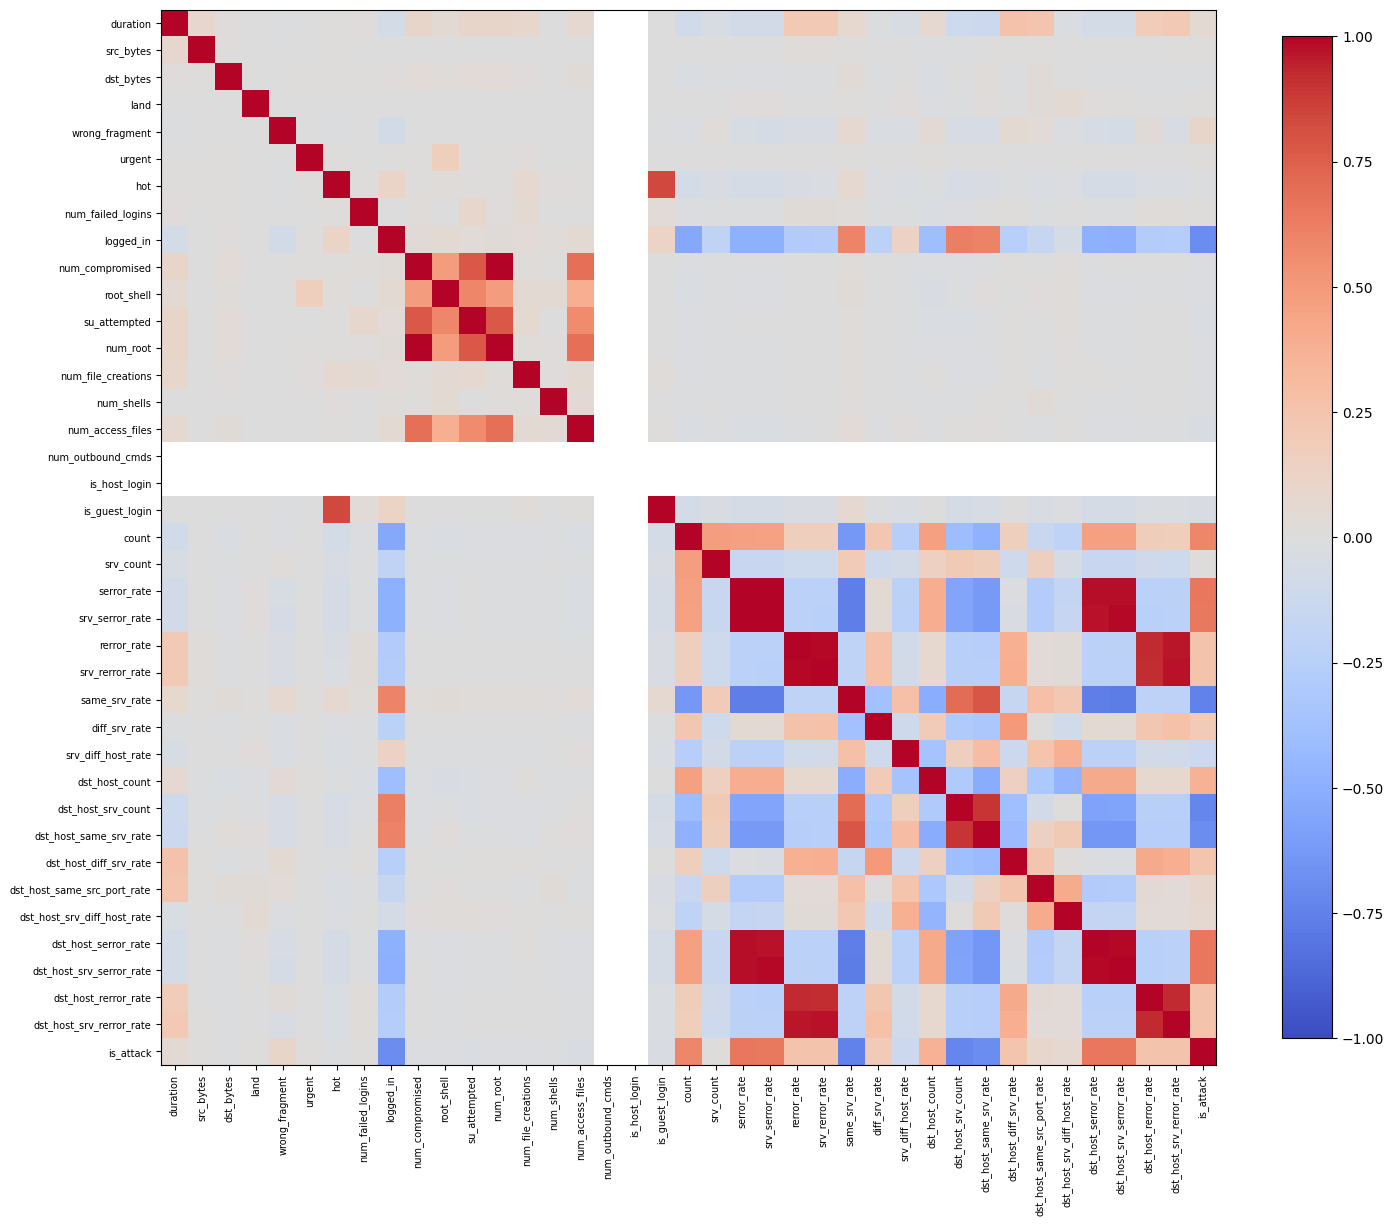

In [ ]:
# numeric features only (exclude level/is_attack-duplicate noise kept for reference)
num_for_corr = df.select_dtypes(include=[np.number]).drop(columns=['level'])
plot_corr(num_for_corr, width=15, height=15, print_value=False)

#### Feature importance — most correlated features to the target `is_attack`

In [ ]:
features_before = get_features_correlated_to_target(num_for_corr, target_feature='is_attack')
features_before.head(12)

,is_attack
same_srv_rate,0.749237
dst_host_srv_count,0.719292
dst_host_same_srv_rate,0.692212
logged_in,0.688084
dst_host_srv_serror_rate,0.653759
dst_host_serror_rate,0.651050
serror_rate,0.649952
srv_serror_rate,0.647817
count,0.578790
dst_host_count,0.368828


**Discuss:** `same_srv_rate`, `dst_host_srv_count`, `logged_in` and the `serror_rate` family lead.
Notice that `src_bytes`/`dst_bytes` are **near the bottom** despite being intuitively important — keep
this in mind, the log transform will fix it.

### Limits of Pearson's correlation
Pearson only captures **monotonic** (linear-ish) dependency. A clear dependency can give $\rho=0$:

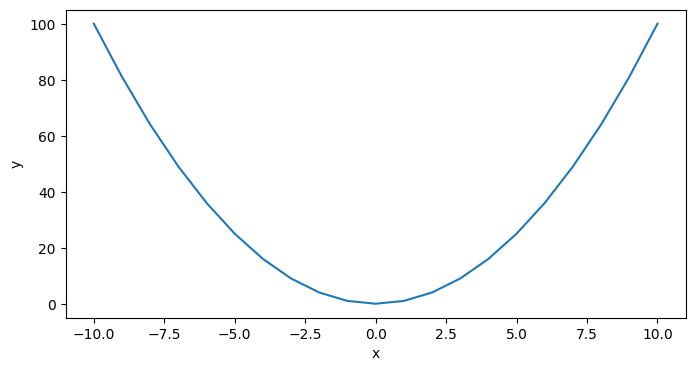

correlation:
      x    y
x  1.0  0.0
y  0.0  1.0


In [ ]:
invented_df = pd.DataFrame({'x': np.arange(-10,11)})
invented_df['y'] = invented_df['x']**2
plt.plot(invented_df['x'], invented_df['y']); plt.xlabel('x'); plt.ylabel('y'); plt.show()
print('correlation:\n', invented_df.corr().round(2))

$y=x^2$ has an obvious dependency but $\rho\approx 0$: before 0 it's decreasing, after 0 increasing,
and the two cancel out. **Zero correlation does not mean independence.**

# Transformation (log)

Correlations are often hidden because some features are heavily **skewed**. Many samples crowd near
low values and a few huge outliers dominate. The fix from the lecture: a logarithmic transform,
using $\log(1+x)$ since $\log(0)$ is undefined.

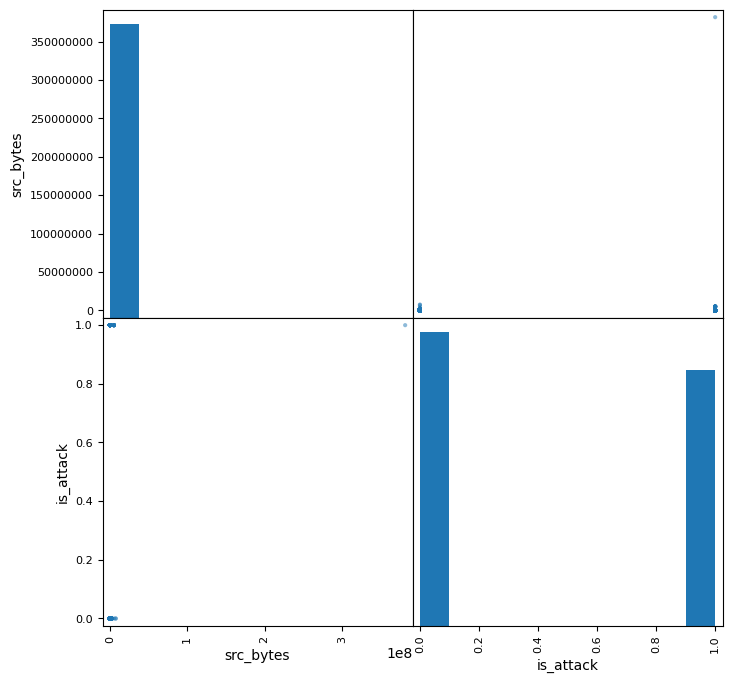

In [ ]:
sm = scatter_matrix(df[['src_bytes','is_attack']], figsize=(8,8)); plt.show()

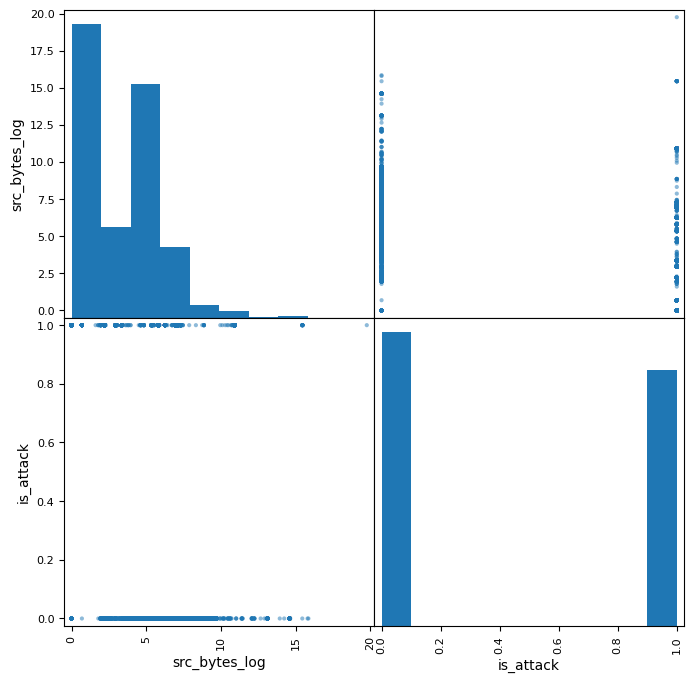

In [ ]:
df['src_bytes_log'] = np.log(1 + df['src_bytes'])
sm = scatter_matrix(df[['src_bytes_log','is_attack']], figsize=(8,8)); plt.show()

In [ ]:
corr = df.corr(numeric_only=True)
print('Original  src_bytes <-> is_attack :', round(corr['src_bytes']['is_attack'],3))
print('After log src_bytes <-> is_attack :', round(corr['src_bytes_log']['is_attack'],3))

Original  src_bytes <-> is_attack : 0.006
After log src_bytes <-> is_attack : -0.729


**This is the key result for our dataset:** the raw correlation of `src_bytes` with attack is
~**0.01** (essentially nothing), but after the log transform its magnitude jumps to ~**0.73**
(ρ ≈ **−0.73**: larger byte counts go with *normal* traffic). The relationship was always there — the outliers were hiding it from Pearson.

#### Transform multiple features at once

In [ ]:
cols_to_transform = ['duration','src_bytes','dst_bytes','count','srv_count',
                     'dst_host_count','dst_host_srv_count']
cols_transformed = [c + '_log' for c in cols_to_transform]
df[cols_transformed] = df[cols_to_transform].transform(lambda x: np.log(1+x))
df[cols_transformed].head()

,duration_log,src_bytes_log,dst_bytes_log,count_log,srv_count_log,dst_host_count_log,dst_host_srv_count_log
0,0.0,6.198479,0.000000,1.098612,1.098612,5.017280,3.258097
1,0.0,4.990433,0.000000,2.639057,0.693147,5.545177,0.693147
2,0.0,0.000000,0.000000,4.820282,1.945910,5.545177,3.295837
3,0.0,5.451038,9.006264,1.791759,1.791759,3.433987,5.545177
4,0.0,5.298317,6.042633,3.433987,3.496508,5.545177,5.545177


Compare feature importance **after** adding the transformed features vs **before**:

In [ ]:
num_after = df.select_dtypes(include=[np.number]).drop(columns=['level'])
features_after = get_features_correlated_to_target(num_after, target_feature='is_attack')
print('TOP 10 AFTER log transform:'); print(features_after.head(10).round(3))

TOP 10 AFTER log transform:
dst_bytes_log               0.753
same_srv_rate               0.749
src_bytes_log               0.729
dst_host_srv_count          0.719
dst_host_same_srv_rate      0.692
logged_in                   0.688
dst_host_srv_count_log      0.675
dst_host_srv_serror_rate    0.654
dst_host_serror_rate        0.651
serror_rate                 0.650
Name: is_attack, dtype: float64


In [ ]:
print('TOP 10 BEFORE (for comparison):'); print(features_before.head(10).round(3))

TOP 10 BEFORE (for comparison):
same_srv_rate               0.749
dst_host_srv_count          0.719
dst_host_same_srv_rate      0.692
logged_in                   0.688
dst_host_srv_serror_rate    0.654
dst_host_serror_rate        0.651
serror_rate                 0.650
srv_serror_rate             0.648
count                       0.579
dst_host_count              0.369
Name: is_attack, dtype: float64


**Discuss:** the log versions of `src_bytes`/`dst_bytes` climb into the top features. We have
*unveiled* correlation that was invisible before — this will help build better models. (A few
features, e.g. `dst_host_count`, correlate slightly less after log; transformation is decided
per feature.)

# Preprocessing — applying what exploration told us

Exploration revealed three problems. Now we **fix** them and show the result of each fix:

1. **Constant features** → drop (no information).
2. **Redundant / duplicate-ish features** (those red clusters in the heatmap) → drop one of each pair.
3. **Heavy skew** in byte/count features → **log transform**.

To keep the pipeline clean and reproducible, we start again from the original 41 features
(ignoring the scratch `_log` columns we made earlier during exploration).

In [ ]:
ORIGINAL_FEATURES = COL_NAMES[:41]   # the 41 raw features (excludes attack, level)
df_clean = df[ORIGINAL_FEATURES + ['attack','category','is_attack']].copy()

n_raw = len(ORIGINAL_FEATURES)
print('Starting from the raw features:', n_raw, 'features | df_clean shape:', df_clean.shape)

Starting from the raw features: 41 features | df_clean shape: (25192, 44)


## Step 1 — drop constant features

A column with a single value everywhere cannot help any model.

In [ ]:
constant = [c for c in df_clean.select_dtypes(include=[np.number]).columns
            if df_clean[c].nunique() == 1]
print('Constant columns found:', constant)

df_clean = df_clean.drop(columns=constant)
n_after_const = n_raw - len(constant)
print(f'Features: {n_raw} -> {n_after_const}   (dropped {len(constant)})')

Constant columns found: ['num_outbound_cmds', 'is_host_login']
Features: 41 -> 39   (dropped 2)


## Step 2 — drop redundant (duplicate-ish) features

These are the glowing red clusters in the correlation heatmap. When two features are almost the same
(|correlation| above a threshold), one of them is redundant. **Rule:** from each highly-correlated pair
we keep the feature *more* correlated with the target `is_attack`, and drop the other.

In [ ]:
def find_redundant(frame, threshold=0.95, target='is_attack'):
    num   = frame.select_dtypes(include=[np.number])
    corr  = num.corr().abs()
    tgt   = corr[target]                      # |corr| of each feature with the target
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))  # avoid double-counting
    report, to_drop = [], set()
    for f1 in upper.columns:
        for f2 in upper.index:
            r = upper.loc[f2, f1]
            if pd.notna(r) and r > threshold and target not in (f1, f2):
                loser = f2 if tgt[f2] <= tgt[f1] else f1   # drop the less-target-correlated one
                report.append((f2, f1, round(r, 3), loser))
                to_drop.add(loser)
    return report, sorted(to_drop)

report, redundant = find_redundant(df_clean, threshold=0.95)

print('Highly-correlated pairs (|r| > 0.95) and the decision:')
for f2, f1, r, loser in report:
    print(f'  {f2:24s} <-> {f1:24s}  r={r}  -> drop {loser}')
print('\nFeatures dropped as redundant:', redundant)

Highly-correlated pairs (|r| > 0.95) and the decision:
  num_compromised          <-> num_root                  r=0.999  -> drop num_compromised
  serror_rate              <-> srv_serror_rate           r=0.993  -> drop srv_serror_rate
  rerror_rate              <-> srv_rerror_rate           r=0.989  -> drop srv_rerror_rate
  serror_rate              <-> dst_host_serror_rate      r=0.978  -> drop serror_rate
  srv_serror_rate          <-> dst_host_serror_rate      r=0.976  -> drop srv_serror_rate
  serror_rate              <-> dst_host_srv_serror_rate  r=0.98  -> drop serror_rate
  srv_serror_rate          <-> dst_host_srv_serror_rate  r=0.985  -> drop srv_serror_rate
  dst_host_serror_rate     <-> dst_host_srv_serror_rate  r=0.985  -> drop dst_host_serror_rate
  rerror_rate              <-> dst_host_srv_rerror_rate  r=0.965  -> drop rerror_rate
  srv_rerror_rate          <-> dst_host_srv_rerror_rate  r=0.97  -> drop srv_rerror_rate

Features dropped as redundant: ['dst_host_serror_rate

In [ ]:
df_clean = df_clean.drop(columns=redundant)
n_after_dedup = n_after_const - len(redundant)
print(f'Features: {n_after_const} -> {n_after_dedup}   (dropped {len(redundant)} redundant)')

Features: 39 -> 33   (dropped 6 redundant)


**See the result:** re-draw the correlation heatmap on the cleaned features. Compare it with the
first heatmap — the dense red `serror`/`rerror` blocks are gone, so the remaining features are far less
redundant.

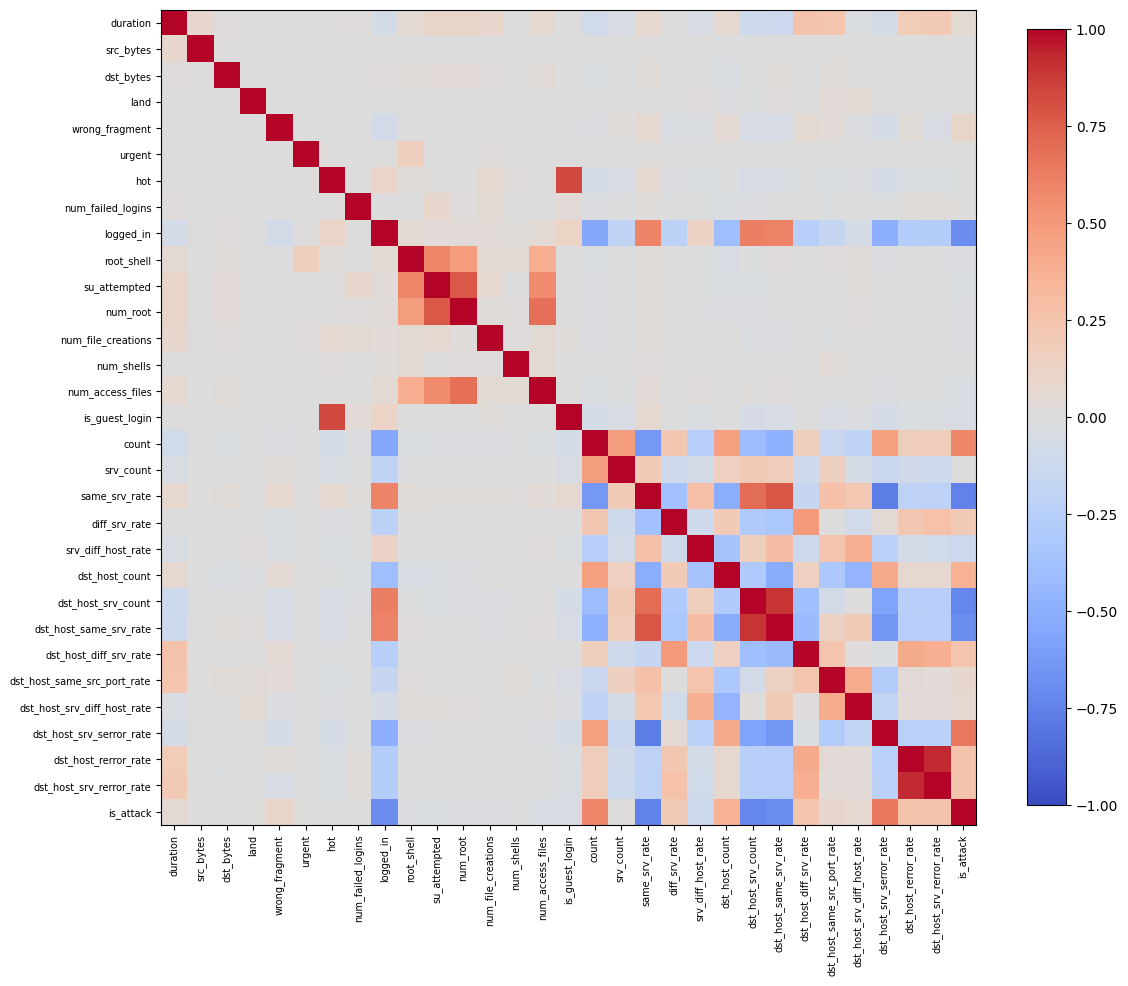

In [ ]:
plot_corr(df_clean.select_dtypes(include=[np.number]), width=12, height=12, print_value=False)

## Step 3 — log-transform the skewed magnitude features

The byte/count features are crushed by huge outliers. We replace each with $\log(1+x)$. The table below
shows, for every transformed feature, its **skew** and its **correlation with the attack label**
*before* vs *after* — the payoff is dramatic for `src_bytes` and `dst_bytes`.

In [ ]:
to_log = ['duration','src_bytes','dst_bytes','count','srv_count',
          'dst_host_count','dst_host_srv_count','num_root','hot',
          'num_file_creations','num_access_files']
to_log = [c for c in to_log if c in df_clean.columns]   # keep only survivors

# --- capture BEFORE ---
before = pd.DataFrame({
    'skew_before':        df_clean[to_log].skew().round(1),
    'corr_target_before': df_clean[to_log + ['is_attack']].corr()['is_attack'][to_log].round(3),
})

# --- apply log(1+x) in place ---
for c in to_log:
    df_clean[c] = np.log1p(df_clean[c])

# --- capture AFTER ---
after = pd.DataFrame({
    'skew_after':        df_clean[to_log].skew().round(1),
    'corr_target_after': df_clean[to_log + ['is_attack']].corr()['is_attack'][to_log].round(3),
})

comparison = before.join(after)[['skew_before','skew_after','corr_target_before','corr_target_after']]
comparison

,skew_before,skew_after,corr_target_before,corr_target_after
duration,11.5,5.2,0.051,-0.070
src_bytes,157.6,0.3,0.006,-0.729
dst_bytes,54.8,0.5,-0.011,-0.753
count,1.5,0.1,0.579,0.599
srv_count,4.7,0.9,0.002,0.057
dst_host_count,-0.8,-1.7,0.369,0.221
dst_host_srv_count,0.3,-0.4,-0.719,-0.675
num_root,62.3,24.3,-0.020,-0.049
hot,13.6,9.4,-0.013,-0.000
num_file_creations,52.1,30.6,-0.018,-0.027


**Read this table:** `src_bytes` goes from skew ≈ 158 (and |corr| ≈ 0.01 with the label) to a tame
skew and |corr| ≈ 0.73. `dst_bytes` behaves the same. We *unveiled* strong predictors that were
invisible in the raw data. A couple of features barely change — that's fine, log transform helps
per-feature.

## Result of preprocessing

In [ ]:
print('Remaining features:')
print(sorted([c for c in df_clean.columns if c not in ('attack','category','is_attack')]))
print('\ndf_clean shape:', df_clean.shape)

Remaining features:
['count', 'diff_srv_rate', 'dst_bytes', 'dst_host_count', 'dst_host_diff_srv_rate', 'dst_host_rerror_rate', 'dst_host_same_src_port_rate', 'dst_host_same_srv_rate', 'dst_host_srv_count', 'dst_host_srv_diff_host_rate', 'dst_host_srv_rerror_rate', 'dst_host_srv_serror_rate', 'duration', 'flag', 'hot', 'is_guest_login', 'land', 'logged_in', 'num_access_files', 'num_failed_logins', 'num_file_creations', 'num_root', 'num_shells', 'protocol_type', 'root_shell', 'same_srv_rate', 'service', 'src_bytes', 'srv_count', 'srv_diff_host_rate', 'su_attempted', 'urgent', 'wrong_fragment']

df_clean shape: (25192, 36)


## Finish: encode categoricals, split, save

Turn text columns into numbers (one-hot), then do the train/test split and save the clean dataset
for the next notebook.

In [ ]:
# missing values check (NSL-KDD is clean)
print('total missing values:', df_clean.isnull().sum().sum())

# one-hot encode the categorical features
df_encoded = pd.get_dummies(df_clean, columns=['protocol_type','flag','service'],
                            prefix=['protocol_type','flag','service'])
n_after_onehot = df_encoded.drop(columns=['attack','category','is_attack']).shape[1]
print(f'After one-hot encoding: {n_after_dedup} numeric features expand to {n_after_onehot} columns')

total missing values: 0
After one-hot encoding: 33 numeric features expand to 110 columns


In [ ]:
from sklearn.model_selection import train_test_split
X = df_encoded.drop(columns=[c for c in ['attack','category','is_attack'] if c in df_encoded.columns])
X = X.select_dtypes(include=[np.number, 'bool']).astype(float)
y = df_encoded['is_attack']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
print('X_train', X_train.shape, '| X_test', X_test.shape)
print('train attack rate', round(y_train.mean(),3), '| test', round(y_test.mean(),3))

X_train (18894, 110) | X_test (6298, 110)
train attack rate 0.466 | test 0.466


In [ ]:
df_encoded.to_csv('KDD_20Percent_clean.csv', index=False)
print('saved KDD_20Percent_clean.csv', df_encoded.shape)

saved KDD_20Percent_clean.csv (25192, 113)


### Before / after summary of the pipeline

In [ ]:
print(f'{"raw features":35s}: {n_raw}')
print(f'{"after dropping constants":35s}: {n_after_const}   (-{n_raw - n_after_const})')
print(f'{"after dropping redundant":35s}: {n_after_dedup}   (-{n_after_const - n_after_dedup})')
print(f'{"after one-hot encoding":35s}: {n_after_onehot}   (categoricals expanded)')
print(f'{"+ log-transformed features":35s}: {len(to_log)}  (values replaced, not added)')

raw features                       : 41
after dropping constants           : 39   (-2)
after dropping redundant           : 33   (-6)
after one-hot encoding             : 110   (categoricals expanded)
+ log-transformed features         : 11  (values replaced, not added)


# Summary — findings & what we did

**Findings (exploration):**
1. No missing values; 25,192 rows, 41 features.
2. Binary task balanced (~53/47); multi-class severely imbalanced (DoS huge, U2R ≈ 11, R2L ≈ 200).
3. Two constant features carry no information.
4. Heavy skew in byte/count features hides correlations.
5. Redundant `serror`/`rerror`/`dst_host_*` clusters (|ρ| ≈ 0.98).
6. Categorical `flag`/`protocol_type` are strongly attack-related.

**What preprocessing did (and the result):**
- Dropped **2 constant** features.
- Dropped **redundant** features (keeping the more predictive one of each pair) — heatmap clusters gone.
- **Log-transformed** skewed magnitude features → `src_bytes`/`dst_bytes` correlation with the label
  jumped from ~0.01 to ~0.73–0.75.
- One-hot encoded categoricals; produced a clean `X`, `y` and saved `KDD_20Percent_clean.csv`.

**Next lesson:** Supervised Learning — Linear / Polynomial Regression, then Logistic Regression for the
binary attack/normal task using the clean `X`, `y` prepared above.